## 텍스트 요약을 위한 LLM을 만들고 고도화 시켜보자
- 야놀자 호텔의 리뷰를 요약하는 모델을 만들고 성능을 향상시키기

In [1]:
import os
import json
import numpy as np
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv
import datetime
from dateutil import parser
# dateutil : 다양한 형식의 날짜와 시간 문자열을 파싱하고 시간대 정보를 처리하는 모듈
 # parser : 문자열에서 날짜와 시간정보를 자동으로 인식하고 파싱하는 함수

### 1. API key 및 기본 설정

In [4]:
load_dotenv()
MY_API_KEY = os.getenv('OPENAI_API_KEY')

client = OpenAI(api_key=MY_API_KEY)

In [ ]:
# 잘 연결됐는지 확인

completion = client.chat.completions.create(
    model='gpt-3.5-turbo',
    messages=[{'role':'user', 'content':'hi'}],
    temperature=1
)
print(completion.choices[0].message.content)

Hello! How can I assist you today?


### 2. 데이터 전처리
- JSON 형태의 리뷰 파일에서 각 리뷰들을 구분할 수 있는 문자열로 변환

#### 1) 수집한 리뷰 JSON 파일 로드
- 야놀자 홈페이지에서 신라스테이 역삼 호텔에 대한 리뷰를 20스크롤 정도 크롤링한 데이터 (23년 8월~24년 10월)

In [6]:
with open('data/ya_review_sinla.json', 'r', encoding='utf-8') as f :
    review_list = json.load(f)

print(len(review_list))
review_list[:10]

420


[{'review': '고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.',
  'stars': 5,
  'date': '2024.06.03'},
 {'review': '커피쿠폰도 받았구 깨끗하고 교회뷰도 이뻤어요!!!', 'stars': 5, 'date': '2022.11.20'},
 {'review': '잊을수없는 추억을 남겼어요 너무너무 좋았어요\r\n여자친구 몰래 프로포즈를 준비하게되었는데\r\n프론트 체크인 도와주셨던 직원분께 양해를 구하고\r\n선물을 미리 맡겨주셨고 프로포즈셋팅까지 완벽하게 진행될 수 있도록 정말 많은 도움 주셨어요\r\n바쁘신 와중에도 제가 계획한대로 체크인도 도와주셨고 딜라이브 ott까지 챙겨주시는 섬세함에 감동받았습니다 나중에 기념일때 다시한번 꼭 방문하겠습니다 성함을 기억했어야 하는데 젊은 남직원분\r\n다음번 방문때 감사인사 드리겠습니다\r\n훌륭한 룸컨디션도 칭찬합니다',
  'stars': 5,
  'date': '2022.10.17'},
 {'review': '조식이 맛있어요!!다양하게 종류도 많구요 캠페인중이여서 할인도 해서 먹었는데 맛있습니다\n직원분들 친절하고 대응도 잘해주세요',
  'stars': 5,
  'date': '1일 전'},
 {'review': '가족들이 간다고 해서 진짜 폭풍 검색해서 알아봐드렸는데 좋아하셔서 좋았습니다 :) 신라스테이는 어딜 가도 좋은것 같아요',
  'stars': 5,
  'date': '3일 전'},
 {'review': '프론트 직원분들이 친절하셔서 좋아요', 'stars': 5, 'date': '3일 전'},
 {'review': '아주좋아요오오옹오ㅗ옹', 'stars': 5, 'date': '2024.10.08'},
 {'review': '청결하고 좋습니다 특히 조식이 맛있었어요', 'stars': 5, 'date': '2024.10.08'},
 {'review': '깨끗

#### 2) 높은 평점 및 낮은 평점 기준 정의
(야놀자 리뷰 요약 중에서 높은 평점만 사용할 예정)
- 전체 평균 4.7이므로 높은 평점은 5점으로 정의
- 높은 평점 : 별 5개
- 낮은 평점 : 별 4개 이하

In [7]:
star_list = [i['stars'] for i in review_list]

np.mean(star_list)

np.float64(4.754761904761905)

<Axes: ylabel='count'>

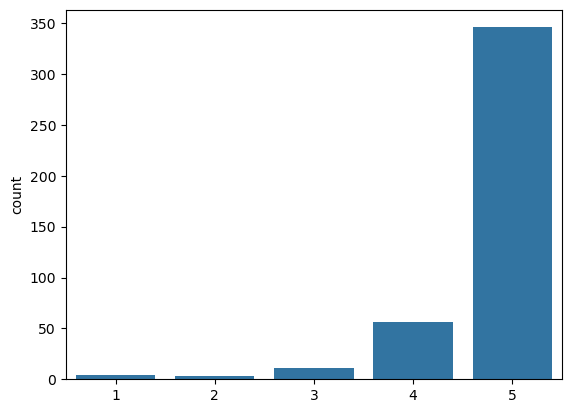

In [8]:
# 점수별 데이터 개수
sns.countplot(x=star_list)

In [9]:
# 높은 평점, 낮은 평점 개수 구하기
high_cnt, low_cnt = 0, 0

for i in review_list :
    if i['stars'] == 5:
        high_cnt += 1
    else :
        low_cnt += 1

high_cnt, low_cnt

(346, 74)

#### 3) 높은 평점만 추출
- 야놀자 홈페이지의 높은 평점리뷰 요약과 비교를 할 예정. 우리도 높은 평점 리뷰만 추출.

In [ ]:
reviews_high = []

for i in review_list :
    if i['stars'] == 5:

        #평점 5점인 리뷰를 시작과 끝 구분기호로 처리해줌
        reviews_high.append('[Review_start]'+ i['review'] + '[Review_end]')

reviews_high[:5]

### 리스트 컴프리헨션 사용!!
# reviews_high = [f"[Review_start]{i['review']}[Review_end]" for i in review_list if i['stars'] == 5]

['[Review_start]고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.[Review_end]',
 '[Review_start]커피쿠폰도 받았구 깨끗하고 교회뷰도 이뻤어요!!![Review_end]',
 '[Review_start]잊을수없는 추억을 남겼어요 너무너무 좋았어요\r\n여자친구 몰래 프로포즈를 준비하게되었는데\r\n프론트 체크인 도와주셨던 직원분께 양해를 구하고\r\n선물을 미리 맡겨주셨고 프로포즈셋팅까지 완벽하게 진행될 수 있도록 정말 많은 도움 주셨어요\r\n바쁘신 와중에도 제가 계획한대로 체크인도 도와주셨고 딜라이브 ott까지 챙겨주시는 섬세함에 감동받았습니다 나중에 기념일때 다시한번 꼭 방문하겠습니다 성함을 기억했어야 하는데 젊은 남직원분\r\n다음번 방문때 감사인사 드리겠습니다\r\n훌륭한 룸컨디션도 칭찬합니다[Review_end]',
 '[Review_start]조식이 맛있어요!!다양하게 종류도 많구요 캠페인중이여서 할인도 해서 먹었는데 맛있습니다\n직원분들 친절하고 대응도 잘해주세요[Review_end]',
 '[Review_start]가족들이 간다고 해서 진짜 폭풍 검색해서 알아봐드렸는데 좋아하셔서 좋았습니다 :) 신라스테이는 어딜 가도 좋은것 같아요[Review_end]']

In [14]:
# 리스트에 있는 리뷰들 전체를 하나의 문자열로 변환 (LLM 입력 형태는 단일 문자열)
reviews_high_txt = '\n'.join(reviews_high)
print(reviews_high_txt[:400])


[Review_start]고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.[Review_end]
[Review_start]커피쿠폰도 받았구 깨끗하고 교회뷰도 이뻤어요!!![Review_end]
[Review_start]잊을수없는 추억을 남겼어요 너무너무 좋았어요
여자친구 몰래 프로포즈를 준비하게되었는데
프론트 체크인 도와주셨던 직원분께 양해를 구하고
선물을 미리 맡겨주셨고 프로포즈셋팅까지 완벽하게 진행될 수 있도록 정말 많은 도움 주셨어요
바쁘신 와중에도 제가 계획한대로 체크인도 도와주셨고 딜라이브 ott까지 챙겨주시는 섬세함에 감동받았습니다 나중에 기념일때 다시한번 꼭 방문하겠습니다 성함을 기억했어야 하


#### 4) 각 전처리 단계를 하나의 함수로 작성~
- 추가로 야놀자 홈페이지에서 GPT-4로 요약한 후기의 기간이 24년 10월 16일부터 이전 6개월간이므로
- 동일한 조건으로 맞춰주기 위해, 현재 리뷰 데이터도 같은 기간의 리뷰만 추출

In [16]:
# 6개월간의 리뷰만 추출하기 위해 기간 지정
# timedelta : 두 날짜 혹은 시간간의 차이를 나타내는 함수
 # 매개변수는 weeks, days, hours, minutes, seconds
 # timedelta는 고정된 길이를 반환하는데 월 단위는 28~31일 사이로 변환되어 길이가 다르고,
 # 이에 따라 년도 마찬가지로 변화되기 때문에 월과 년 기준은 없음
datetime.datetime(2024,10,16) - datetime.timedelta(weeks=24)

datetime.datetime(2024, 5, 1, 0, 0)

In [ ]:
# 리뷰 전처리 함수
def preprocess_reviews(path='data/ya_review_sinla.json') : 
    with open(path, 'r', encoding='utf-8') as f :
        review_list = json.load(f)

    review_high = []

    # 기준 날짜 (데이터가 수집된 당시 기준)
    base_date = datetime.datetime(2024,10,16)

    # 6개월 전 날짜
    date_boundary = base_date - datetime.timedelta(weeks=24)

    for i in review_list :
        # 각 리뷰의 날짜를 변수에 저장 (문자열 상태)
        review_date_str = i['date']
        
        try :
            # parse : 문자열이 들어오면 코드 타입(날짜형태)으로 변환시켜주는 함수
            review_date = parser.parse(review_date_str)
        
            # 만약 에러가 발생한다면, 년월일로 표시되지 않은 데이터 값들은 parse 함수 사용시 해당 에러가 발생 ex) 2일전
            # 해당 데이터는 그냥 현재 날짜로 변경 (어차피 몇일전은 6개월 내에 포함되니까~)
        except (ValueError, TypeError) :
            review_date = base_date

        
        # 리뷰 날짜가 6개월 날짜보다 작으면(이전이면) 수집 안하고 반복문으로 돌아가
        if review_date < date_boundary :
            continue

        if i['stars'] == 5 :
            review_high.append('[Review_start]' + i['review'] + '[Review_end]')

    # 리뷰들을 개행 주어 구분하며 전체 문자열로 변환
    reviews_high_text = '\n'.join(review_high)

    return reviews_high_text

In [ ]:
# review_date = parser.parse(review_date_str)
# type(review_date)
# 타입 찍어보니, datetime.datetime

datetime.datetime

In [21]:
# 전처리 함수 실행
reviews = preprocess_reviews()
print(reviews)

[Review_start]고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.[Review_end]
[Review_start]조식이 맛있어요!!다양하게 종류도 많구요 캠페인중이여서 할인도 해서 먹었는데 맛있습니다
직원분들 친절하고 대응도 잘해주세요[Review_end]
[Review_start]가족들이 간다고 해서 진짜 폭풍 검색해서 알아봐드렸는데 좋아하셔서 좋았습니다 :) 신라스테이는 어딜 가도 좋은것 같아요[Review_end]
[Review_start]프론트 직원분들이 친절하셔서 좋아요[Review_end]
[Review_start]아주좋아요오오옹오ㅗ옹[Review_end]
[Review_start]청결하고 좋습니다 특히 조식이 맛있었어요[Review_end]
[Review_start]깨끗하고 친잘하고 교통편도 편리해요
그래서 출장중엔 종종 이용합니다[Review_end]
[Review_start]서울오면 항상들려요~[Review_end]
[Review_start]잘 아용하였습니다![Review_end]
[Review_start]편안하게 잘 쉬다 갑니다.[Review_end]
[Review_start]조식도 맛있고 주차도 편리하고 좋았습니다^^[Review_end]
[Review_start]처음 가보았는데 도시에 있어도 소음이 심하지도 않고 객실은 대체적으로 청결하고 좋았습니다[Review_end]
[Review_start]병원 방문으로 강남에 갔다가 쉴 곳이 필요해 데이유즈로 이용했습니다. 전체적으로 룸 컨디션은 5성급 호텔과 비슷한 수준으로 훌륭했고, 인근에 식당과 카페가 많이 있어 위치도 좋습니다. 
무엇보다 넓은 지하주차장을 가지고 있어, 어딜 가나 주차 스트레스가 심한 강남에서 편히 쉬다 갈 수 있었습니다.[Review_end]
[Review_start]시설이 깨끗하고 편리하게 이용함[Review_end]
[Review_start]친절 하고 깨끗해요[Re

### 3. 리뷰 문장 요약을 위한 Base 모델 개발
- base 모델(gpt-3.5-turbo)의 요약이 야놀자 후기 요약문장(gpt-4-turbo)에 근접하게 성능을 향상시켜보자

In [22]:
len(reviews)

6916

In [23]:
# 베이스 프롬프트 작성
PROMPT_BASELINE = '아래 숙소 리뷰에 대해 5문장 내로 요약해줘'

#### 1) 리뷰 요약 함수 선언

In [24]:
# LLM을 호출하여 리뷰들에 대한 요약을 진행하는 사용자 정의 함수
def summarize(reviews, prompt, temperature=0, model='gpt-3.5-turbo') :
    prompt = prompt + '\n\n' + reviews

    completion = client.chat.completions.create(
        model=model,
        messages=[{'role':'user', 'content':prompt}],
        temperature=temperature
    )

    return completion.choices[0].message.content

#### 2) 모델별 요약 결과

In [25]:
# base 모델 요약 결과
print(summarize(reviews, PROMPT_BASELINE))

조식포함으로 결정한 숙소는 시설, 서비스, 청결도 모두 만족스러웠고, 직원분들도 친절했다. 위치도 좋아서 가족들이 좋아했다.


In [26]:
# gpt-4-turbo 요약 결과
summary_gpt4_turbo = """청결하고 쾌적한 환경을 제공하며, 친절한 직원 서비스가 돋보입니다. 
조식은 다양한 메뉴와 맛으로 손님들에게 호평을 받으며, 주차 시설도 편리하게 마련되어 있습니다. 
객실은 아늑하고 고급스러운 분위기를 연출하며, 일부 객실에서는 도로 소음이 발생할 수 있습니다. 
접근성과 주변 식당, 카페가 다양해 이용객의 편의성이 높습니다. 전반적으로 가성비가 우수하고, 재방문 의사가 있는 곳입니다."""

### 4. 모델 평가 함수 선언
#### 1) 평가 기준 설정
- MT-Bench 논문 기반 LLM 비교 평가 방식 적용
- gpt-4o 모델 활용하여 2개의 모델(gpt-3.5-turbo, gpt-4-turbo)의 요약 결과를 평가해보자
#### 2) 평가를 위한 스크립트 및 모델 실행 코드 작성
- 기존 MT-Bench 논문의 프롬프트에서 우리의 task에 맞게 일부만 수정해서 활용

In [27]:
def pairwise_eval(reviews, answer_a, answer_b) :
    eval_prompt = f"""[System]
    Please act as an impartial judge and evaluate the quality of the Korean summaries provided by two
    AI assistants to the set of user reviews on accommodations displayed below. You should choose the assistant that
    follows the user's instructions and answers the user's question better. Your evaluation
    should consider factors such as the helpfulness, relevance, accuracy, depth, creativity,
    and level of detail of their responses. Begin your evaluation by comparing the two
    responses and provide a short explanation. Avoid any position biases and ensure that the
    order in which the responses were presented does not influence your decision. Do not allow
    the length of the responses to influence your evaluation. Do not favor certain names of
    the assistants. Be as objective as possible. After providing your explanation, output your
    final verdict by strictly following this format: "[[A]]" if assistant A is better, "[[B]]"
    if assistant B is better, and "[[C]]" for a tie.
    [User Reviews]
    {reviews}
    [The Start of Assistant A's Answer]
    {answer_a}
    [The End of Assistant A's Answer]
    [The Start of Assistant B's Answer]
    {answer_b}
    [The End of Assistant B's Answer]"""
        
    # 평가를 위한 LLM은 GPT-4o 버전으로 지정
    completion = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': eval_prompt}],
        temperature=0
    )
    return completion.choices[0].message.content

#### 3) base모델과 4모델 하나씩의 응답에 대해서 시범 평가

In [29]:
answer_a = summarize(reviews, PROMPT_BASELINE)
answer_b = summary_gpt4_turbo

pairwise_eval(reviews, answer_a, answer_b)

"Assistant A's summary is concise and focuses on the positive aspects of the accommodation, such as the satisfaction with the breakfast, facilities, service, cleanliness, and the friendliness of the staff. It also mentions the good location and the intention to revisit, which aligns with the user reviews.\n\nAssistant B's summary provides a more detailed overview, highlighting the cleanliness, comfort, and friendly service. It also mentions the variety and quality of the breakfast, convenient parking, and the cozy and luxurious atmosphere of the rooms. Additionally, it notes the potential for road noise in some rooms and the accessibility to nearby dining options. The summary concludes with a mention of the good value for money and the likelihood of guests returning.\n\nWhile both summaries capture the essence of the user reviews, Assistant B offers a more comprehensive and detailed summary, covering a wider range of aspects mentioned in the reviews, such as parking, room atmosphere, a